# Value-Bin-by-Delay MVPA — Aggregate Results (Josh ROIs)

Loads outputs from the three Slurm jobs (one per delay bin) and summarises:
1. ROI availability and subject/voxel counts
2. Balanced accuracy vs chance per ROI x delay bin
3. Per-class AUC (A1/A2/A3)
4. Per-class precision / recall / F1
5. Confusion matrices
6. Subject-level prediction summaries

**Atlas:** josh_orig (8 ROIs: L/R Caudate, L/R NACC, L/R Precentral, L/R OFCmed)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dd_kable_analysis.config_loader import load_config

cfg = load_config()

ANALYSIS_TAG = 'value_bins_by_delay_josh_orig'
RESULTS_ROOT = Path(cfg.output_root) / f'mvpa_{ANALYSIS_TAG}'
DELAY_BINS = [1, 2, 3]
DELAY_LABELS = {1: 'D1 (short)', 2: 'D2 (mid)', 3: 'D3 (long)'}
CHANCE = 1 / 3

JOSH_LABELS = {
    1: 'L_Caudate',
    2: 'R_Caudate',
    3: 'L_NACC',
    4: 'R_NACC',
    5: 'Precentral_L',
    6: 'Precentral_R',
    7: 'OFCmed_L',
    8: 'OFCmed_R',
}

print('Results root:', RESULTS_ROOT)
for d in DELAY_BINS:
    p = RESULTS_ROOT / f'delay_bin_{d}'
    success = (p / '_SUCCESS').exists()
    print(f'  delay_bin={d}: {"OK" if success else "NOT DONE"}')

Results root: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/analysis_results/mvpa_value_bins_by_delay_josh_orig
  delay_bin=1: OK
  delay_bin=2: OK
  delay_bin=3: OK


In [15]:
# pull out bin cutoffs
import json
from pathlib import Path

meta = json.loads(
    (
        Path(cfg.output_root)
        / 'mvpa_value_bins_by_delay_josh_orig/delay_bin_1/meta.json'
    ).read_text()
)
print('Delay edges:', meta['bin_edges']['delay_edges'])
print('Value edges:', meta['bin_edges']['value_edges'])


Delay edges: [74.0, 128.0]
Value edges: [35.0, 58.0]


---
## 1. Load outputs

In [2]:
roi_summary_parts = []
subject_preds_parts = []
confusion_parts = []
meta_all = {}

for d in DELAY_BINS:
    d_dir = RESULTS_ROOT / f'delay_bin_{d}'
    if not (d_dir / '_SUCCESS').exists():
        print(f'delay_bin={d} not complete, skipping')
        continue
    roi_summary_parts.append(pd.read_csv(d_dir / 'roi_summary.csv'))
    subject_preds_parts.append(pd.read_csv(d_dir / 'subject_preds.csv'))
    confusion_parts.append(pd.read_csv(d_dir / 'confusion_matrix.csv'))
    meta_all[d] = json.loads((d_dir / 'meta.json').read_text())

roi_df = pd.concat(roi_summary_parts, ignore_index=True)
pred_df = pd.concat(subject_preds_parts, ignore_index=True)
conf_df = pd.concat(confusion_parts, ignore_index=True)

roi_df['roi_name'] = roi_df['roi_label'].map(JOSH_LABELS)
pred_df['roi_name'] = pred_df['roi_label'].map(JOSH_LABELS)
conf_df['roi_name'] = conf_df['roi_label'].map(JOSH_LABELS)

print(f'roi_df shape:  {roi_df.shape}')
print(f'pred_df shape: {pred_df.shape}')
print(f'conf_df shape: {conf_df.shape}')
roi_df.head()

roi_df shape:  (21, 22)
pred_df shape: (7560, 10)
conf_df shape: (189, 6)


,roi_label,delay_bin,n_subjects,n_patterns,n_vox,chance_level,accuracy,balanced_accuracy,mean_C,precision_A1,...,auc_A1,precision_A2,recall_A2,f1_A2,auc_A2,precision_A3,recall_A3,f1_A3,auc_A3,roi_name
0,1,1,120,360,1808,0.333333,0.325000,0.325000,0.000100,0.342593,...,0.529653,0.303922,0.258333,0.279279,0.471597,0.326667,0.408333,0.362963,0.490486,L_Caudate
1,2,1,120,360,1021,0.333333,0.325000,0.325000,0.000100,0.349206,...,0.517188,0.315217,0.241667,0.273585,0.450521,0.309859,0.366667,0.335878,0.473160,R_Caudate
2,3,1,120,360,315,0.333333,0.369444,0.369444,0.000324,0.393443,...,0.571319,0.348315,0.258333,0.296651,0.493924,0.362416,0.450000,0.401487,0.505278,L_NACC
3,4,1,120,360,719,0.333333,0.338889,0.338889,0.000232,0.365517,...,0.512986,0.346154,0.225000,0.272727,0.508715,0.306569,0.350000,0.326848,0.475799,R_NACC
4,5,1,120,360,2870,0.333333,0.322222,0.322222,0.000100,0.328467,...,0.503264,0.270270,0.166667,0.206186,0.451042,0.342282,0.425000,0.379182,0.528056,Precentral_L


---
## 2. QC: subject and voxel counts per ROI x delay bin

In [3]:
print('Subject counts per ROI x delay bin:')
print(
    roi_df.pivot_table(
        index='roi_name', columns='delay_bin', values='n_subjects', aggfunc='first'
    )
    .fillna('-')
    .to_string()
)
print()
print('Voxel counts (post-intersection) per ROI x delay bin:')
print(
    roi_df.pivot_table(
        index='roi_name', columns='delay_bin', values='n_vox', aggfunc='first'
    )
    .fillna('-')
    .to_string()
)

Subject counts per ROI x delay bin:
delay_bin       1    2    3
roi_name                   
L_Caudate     120  120  120
L_NACC        120  120  120
OFCmed_L      120  120  120
Precentral_L  120  120  120
Precentral_R  120  120  120
R_Caudate     120  120  120
R_NACC        120  120  120

Voxel counts (post-intersection) per ROI x delay bin:
delay_bin        1     2     3
roi_name                      
L_Caudate     1808  1808  1808
L_NACC         315   315   315
OFCmed_L       317   317   317
Precentral_L  2870  2870  2870
Precentral_R  2276  2274  2276
R_Caudate     1021  1021  1021
R_NACC         719   719   719


In [4]:
for d, meta in meta_all.items():
    print(f'--- delay_bin={d} ---')
    print(f'  delay edges: {meta["bin_edges"]["delay_edges"]}')
    print(f'  value edges: {meta["bin_edges"]["value_edges"]}')
    sc = meta['subject_counts']
    print(
        f'  subjects: requested={sc["n_subjects_requested"]}  '
        f'beh_ok={sc["n_subjects_beh_ok"]}  '
        f'binned_ok={sc["n_subjects_binned_ok"]}  '
        f'with_delay_bin={sc["n_subjects_with_delay_bin"]}'
    )
    if sc['failed_beh']:
        print(f'  failed beh: {sc["failed_beh"]}')
    if sc['failed_binned']:
        print(f'  failed binned: {sc["failed_binned"]}')
    print()

--- delay_bin=1 ---
  delay edges: [74.0, 128.0]
  value edges: [35.0, 58.0]
  subjects: requested=123  beh_ok=122  binned_ok=122  with_delay_bin=120
  failed beh: ['dmp0063']

--- delay_bin=2 ---
  delay edges: [74.0, 128.0]
  value edges: [35.0, 58.0]
  subjects: requested=123  beh_ok=122  binned_ok=122  with_delay_bin=120
  failed beh: ['dmp0063']

--- delay_bin=3 ---
  delay edges: [74.0, 128.0]
  value edges: [35.0, 58.0]
  subjects: requested=123  beh_ok=122  binned_ok=122  with_delay_bin=120
  failed beh: ['dmp0063']



---
## 2b. ROI exclusion summary (parsed from Slurm logs)

Run the cell below to parse the log files and build a full per-ROI coverage table.
After running, copy the printed table into the markdown cell below it for a permanent record.

In [5]:
import re
from glob import glob
from collections import defaultdict

LOG_DIR = Path(
    '/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/scripts/dd-kable-analysis/logs'
)

log_files = sorted(glob(str(LOG_DIR / 'mvpa_valbins_josh_*.out')))
if not log_files:
    raise FileNotFoundError(f'No Josh ROI log files found in {LOG_DIR}')

job_groups = defaultdict(dict)
for f in log_files:
    stem = Path(f).stem
    parts = stem.split('_')
    array_id, task_id = parts[-2], int(parts[-1])
    job_groups[array_id][task_id] = f

latest_array_id = sorted(job_groups.keys())[-1]
delay_logs = job_groups[latest_array_id]
print(f'Using job array: {latest_array_id}')
for d in sorted(delay_logs):
    print(f'  delay_bin={d}: {delay_logs[d]}')

re_passed = re.compile(r'ROI (\d+): n_subs=(\d+) X=\(\d+, (\d+)\) n_vox_common=\d+')
re_dropped = re.compile(r'ROI (\d+): dropped (\d+) subject')
re_failed = re.compile(r'ROI (\d+): only (\d+) voxels after intersection')

ALL_ROIS = list(range(1, 9))
records = []

for d in sorted(delay_logs):
    text = Path(delay_logs[d]).read_text()
    dropped_subs = {}
    failed_vox = {}
    passed_info = {}

    for line in text.splitlines():
        m = re_dropped.search(line)
        if m:
            dropped_subs[int(m.group(1))] = int(m.group(2))
        m = re_failed.search(line)
        if m:
            failed_vox[int(m.group(1))] = int(m.group(2))
        m = re_passed.search(line)
        if m:
            passed_info[int(m.group(1))] = {
                'n_subs': int(m.group(2)),
                'n_vox': int(m.group(3)),
            }

    for roi in ALL_ROIS:
        if roi in passed_info:
            status = 'PASSED'
            note = f'n_subs={passed_info[roi]["n_subs"]}, n_vox={passed_info[roi]["n_vox"]}'
            if roi in dropped_subs:
                note += f' ({dropped_subs[roi]} sub(s) dropped before intersection)'
        elif roi in failed_vox:
            status = 'FAILED: too few voxels after intersection'
            note = f'{failed_vox[roi]} vox remain'
            if roi in dropped_subs:
                note += f' ({dropped_subs[roi]} sub(s) dropped first)'
        else:
            status = 'EXCLUDED: filtered at per-subject stage'
            note = 'ROI never reached decode (min_voxels_per_roi threshold)'

        records.append(
            {
                'delay_bin': d,
                'roi_label': roi,
                'roi_name': JOSH_LABELS[roi],
                'status': status,
                'note': note,
            }
        )

excl_df = pd.DataFrame(records)

print()
print('ROI COVERAGE TABLE')
print('=' * 80)
for d in sorted(delay_logs):
    print(f'\ndelay_bin={d}:')
    sub = excl_df[excl_df['delay_bin'] == d][
        ['roi_label', 'roi_name', 'status', 'note']
    ]
    print(sub.to_string(index=False))
print()
excl_df

Using job array: 31030126
  delay_bin=1: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/scripts/dd-kable-analysis/logs/mvpa_valbins_josh_31030126_1.out
  delay_bin=2: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/scripts/dd-kable-analysis/logs/mvpa_valbins_josh_31030126_2.out
  delay_bin=3: /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/scripts/dd-kable-analysis/logs/mvpa_valbins_josh_31030126_3.out

ROI COVERAGE TABLE

delay_bin=1:
 roi_label     roi_name                                    status                   note
         1    L_Caudate                                    PASSED n_subs=120, n_vox=1808
         2    R_Caudate                                    PASSED n_subs=120, n_vox=1021
         3       L_NACC                                    PASSED  n_subs=120, n_vox=315
         4       R_NACC                                    PASSED  n_subs=120, n_vox=719
         5 Precentral_L                                    PASSED n_subs=120, n_vox=2870
    

,delay_bin,roi_label,roi_name,status,note
0,1,1,L_Caudate,PASSED,"n_subs=120, n_vox=1808"
1,1,2,R_Caudate,PASSED,"n_subs=120, n_vox=1021"
2,1,3,L_NACC,PASSED,"n_subs=120, n_vox=315"
3,1,4,R_NACC,PASSED,"n_subs=120, n_vox=719"
4,1,5,Precentral_L,PASSED,"n_subs=120, n_vox=2870"
5,1,6,Precentral_R,PASSED,"n_subs=120, n_vox=2276"
6,1,7,OFCmed_L,PASSED,"n_subs=120, n_vox=317"
7,1,8,OFCmed_R,FAILED: too few voxels after intersection,10 vox remain
8,2,1,L_Caudate,PASSED,"n_subs=120, n_vox=1808"
9,2,2,R_Caudate,PASSED,"n_subs=120, n_vox=1021"


### ROI exclusion record (copy printed table here after running cell above)

```
PASTE OUTPUT HERE
```

---
## 3. Balanced accuracy vs chance

Primary summary metric. Chance = 0.333.

In [6]:
print(f'Balanced accuracy (chance = {CHANCE:.3f}):')
print(
    roi_df.pivot_table(
        index='roi_name', columns='delay_bin', values='balanced_accuracy'
    )
    .round(3)
    .to_string()
)

Balanced accuracy (chance = 0.333):
delay_bin         1      2      3
roi_name                         
L_Caudate     0.325  0.367  0.336
L_NACC        0.369  0.353  0.336
OFCmed_L      0.369  0.331  0.361
Precentral_L  0.322  0.383  0.378
Precentral_R  0.325  0.342  0.356
R_Caudate     0.325  0.356  0.350
R_NACC        0.339  0.389  0.339


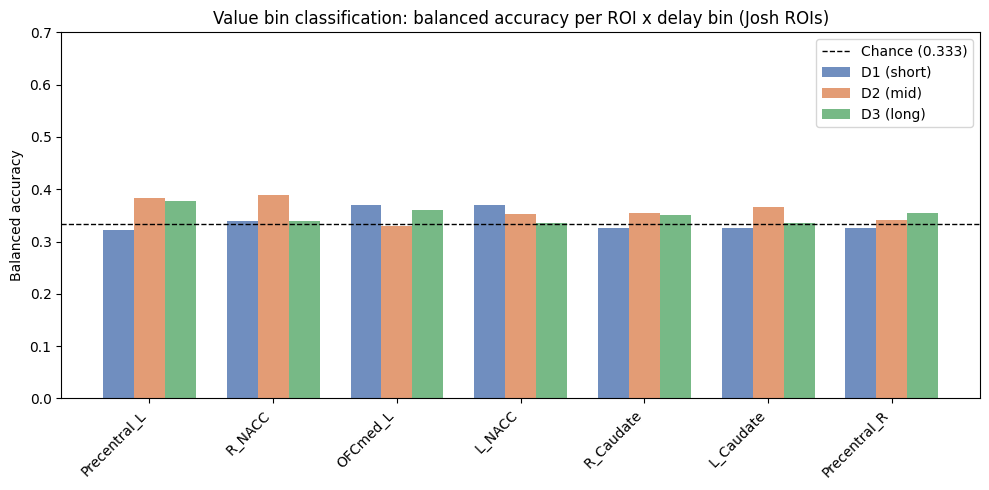

In [7]:
roi_order = (
    roi_df.groupby('roi_name')['balanced_accuracy']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(roi_order))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, d in enumerate(DELAY_BINS):
    subset = roi_df[roi_df['delay_bin'] == d].set_index('roi_name')
    vals = [
        subset.loc[r, 'balanced_accuracy'] if r in subset.index else np.nan
        for r in roi_order
    ]
    ax.bar(
        x + i * width, vals, width, label=DELAY_LABELS[d], color=colors[i], alpha=0.8
    )

ax.axhline(CHANCE, color='k', linestyle='--', linewidth=1, label='Chance (0.333)')
ax.set_xticks(x + width)
ax.set_xticklabels(roi_order, rotation=45, ha='right')
ax.set_ylabel('Balanced accuracy')
ax.set_title(
    'Value bin classification: balanced accuracy per ROI x delay bin (Josh ROIs)'
)
ax.legend()
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

---
## 4. Per-class AUC (one-vs-rest)

Threshold-free discriminability. A1 = low value, A2 = mid, A3 = high. Chance = 0.5.

In [8]:
for vbin, label in [('A1', 'low value'), ('A2', 'mid value'), ('A3', 'high value')]:
    col = f'auc_{vbin}'
    pivot = roi_df.pivot_table(index='roi_name', columns='delay_bin', values=col).round(
        3
    )
    print(f'AUC {vbin} ({label}) — chance = 0.5:')
    print(pivot.to_string())
    print()

AUC A1 (low value) — chance = 0.5:
delay_bin         1      2      3
roi_name                         
L_Caudate     0.530  0.562  0.554
L_NACC        0.571  0.518  0.532
OFCmed_L      0.507  0.535  0.576
Precentral_L  0.503  0.559  0.557
Precentral_R  0.529  0.523  0.551
R_Caudate     0.517  0.486  0.540
R_NACC        0.513  0.546  0.506

AUC A2 (mid value) — chance = 0.5:
delay_bin         1      2      3
roi_name                         
L_Caudate     0.472  0.550  0.492
L_NACC        0.494  0.514  0.475
OFCmed_L      0.493  0.515  0.530
Precentral_L  0.451  0.553  0.537
Precentral_R  0.485  0.527  0.496
R_Caudate     0.451  0.511  0.458
R_NACC        0.509  0.544  0.547

AUC A3 (high value) — chance = 0.5:
delay_bin         1      2      3
roi_name                         
L_Caudate     0.490  0.494  0.528
L_NACC        0.505  0.586  0.506
OFCmed_L      0.498  0.507  0.524
Precentral_L  0.528  0.519  0.525
Precentral_R  0.497  0.527  0.531
R_Caudate     0.473  0.525  0.516
R_NACC  

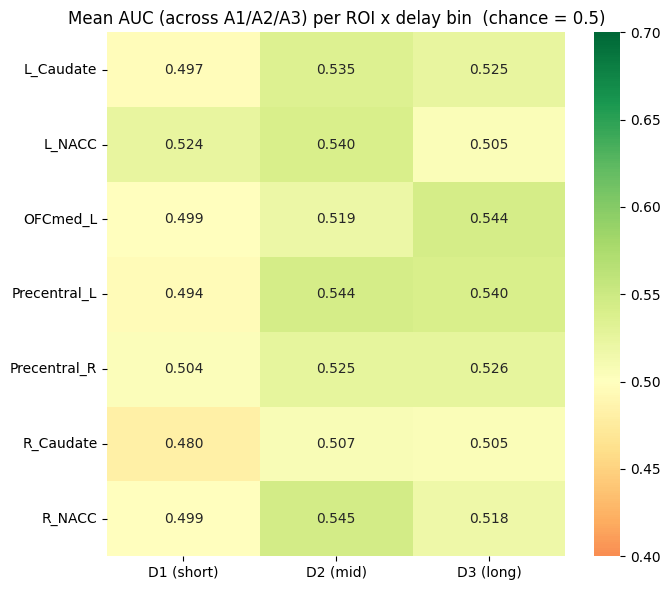

In [9]:
auc_cols = ['auc_A1', 'auc_A2', 'auc_A3']
roi_df['mean_auc'] = roi_df[auc_cols].mean(axis=1)

pivot_auc = roi_df.pivot_table(index='roi_name', columns='delay_bin', values='mean_auc')
pivot_auc.columns = [DELAY_LABELS[c] for c in pivot_auc.columns]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    pivot_auc,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0.4,
    vmax=0.7,
    center=0.5,
    ax=ax,
)
ax.set_title('Mean AUC (across A1/A2/A3) per ROI x delay bin  (chance = 0.5)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 5. Per-class precision / recall / F1

Checks whether the classifier is collapsing to one class.

In [10]:
for metric in ['precision', 'recall', 'f1']:
    print(f'=== {metric.upper()} ===')
    for vbin in ['A1', 'A2', 'A3']:
        col = f'{metric}_{vbin}'
        pivot = roi_df.pivot_table(
            index='roi_name', columns='delay_bin', values=col
        ).round(3)
        print(f'  {vbin}:')
        print(pivot.to_string())
    print()

=== PRECISION ===
  A1:
delay_bin         1      2      3
roi_name                         
L_Caudate     0.343  0.381  0.372
L_NACC        0.393  0.369  0.331
OFCmed_L      0.372  0.350  0.392
Precentral_L  0.328  0.387  0.368
Precentral_R  0.348  0.352  0.359
R_Caudate     0.349  0.324  0.349
R_NACC        0.366  0.375  0.320
  A2:
delay_bin         1      2      3
roi_name                         
L_Caudate     0.304  0.393  0.286
L_NACC        0.348  0.342  0.318
OFCmed_L      0.375  0.327  0.337
Precentral_L  0.270  0.382  0.400
Precentral_R  0.324  0.339  0.368
R_Caudate     0.315  0.360  0.314
R_NACC        0.346  0.398  0.361
  A3:
delay_bin         1      2      3
roi_name                         
L_Caudate     0.327  0.307  0.324
L_NACC        0.362  0.347  0.359
OFCmed_L      0.363  0.301  0.336
Precentral_L  0.342  0.378  0.367
Precentral_R  0.305  0.330  0.341
R_Caudate     0.310  0.378  0.384
R_NACC        0.307  0.398  0.339

=== RECALL ===
  A1:
delay_bin         1     

---
## 6. Confusion matrices

Colour = row-normalised rate; number = raw count.
Errors concentrated on adjacent bins (A1<->A2, A2<->A3) suggest ordinal encoding
even when overall accuracy is near chance.

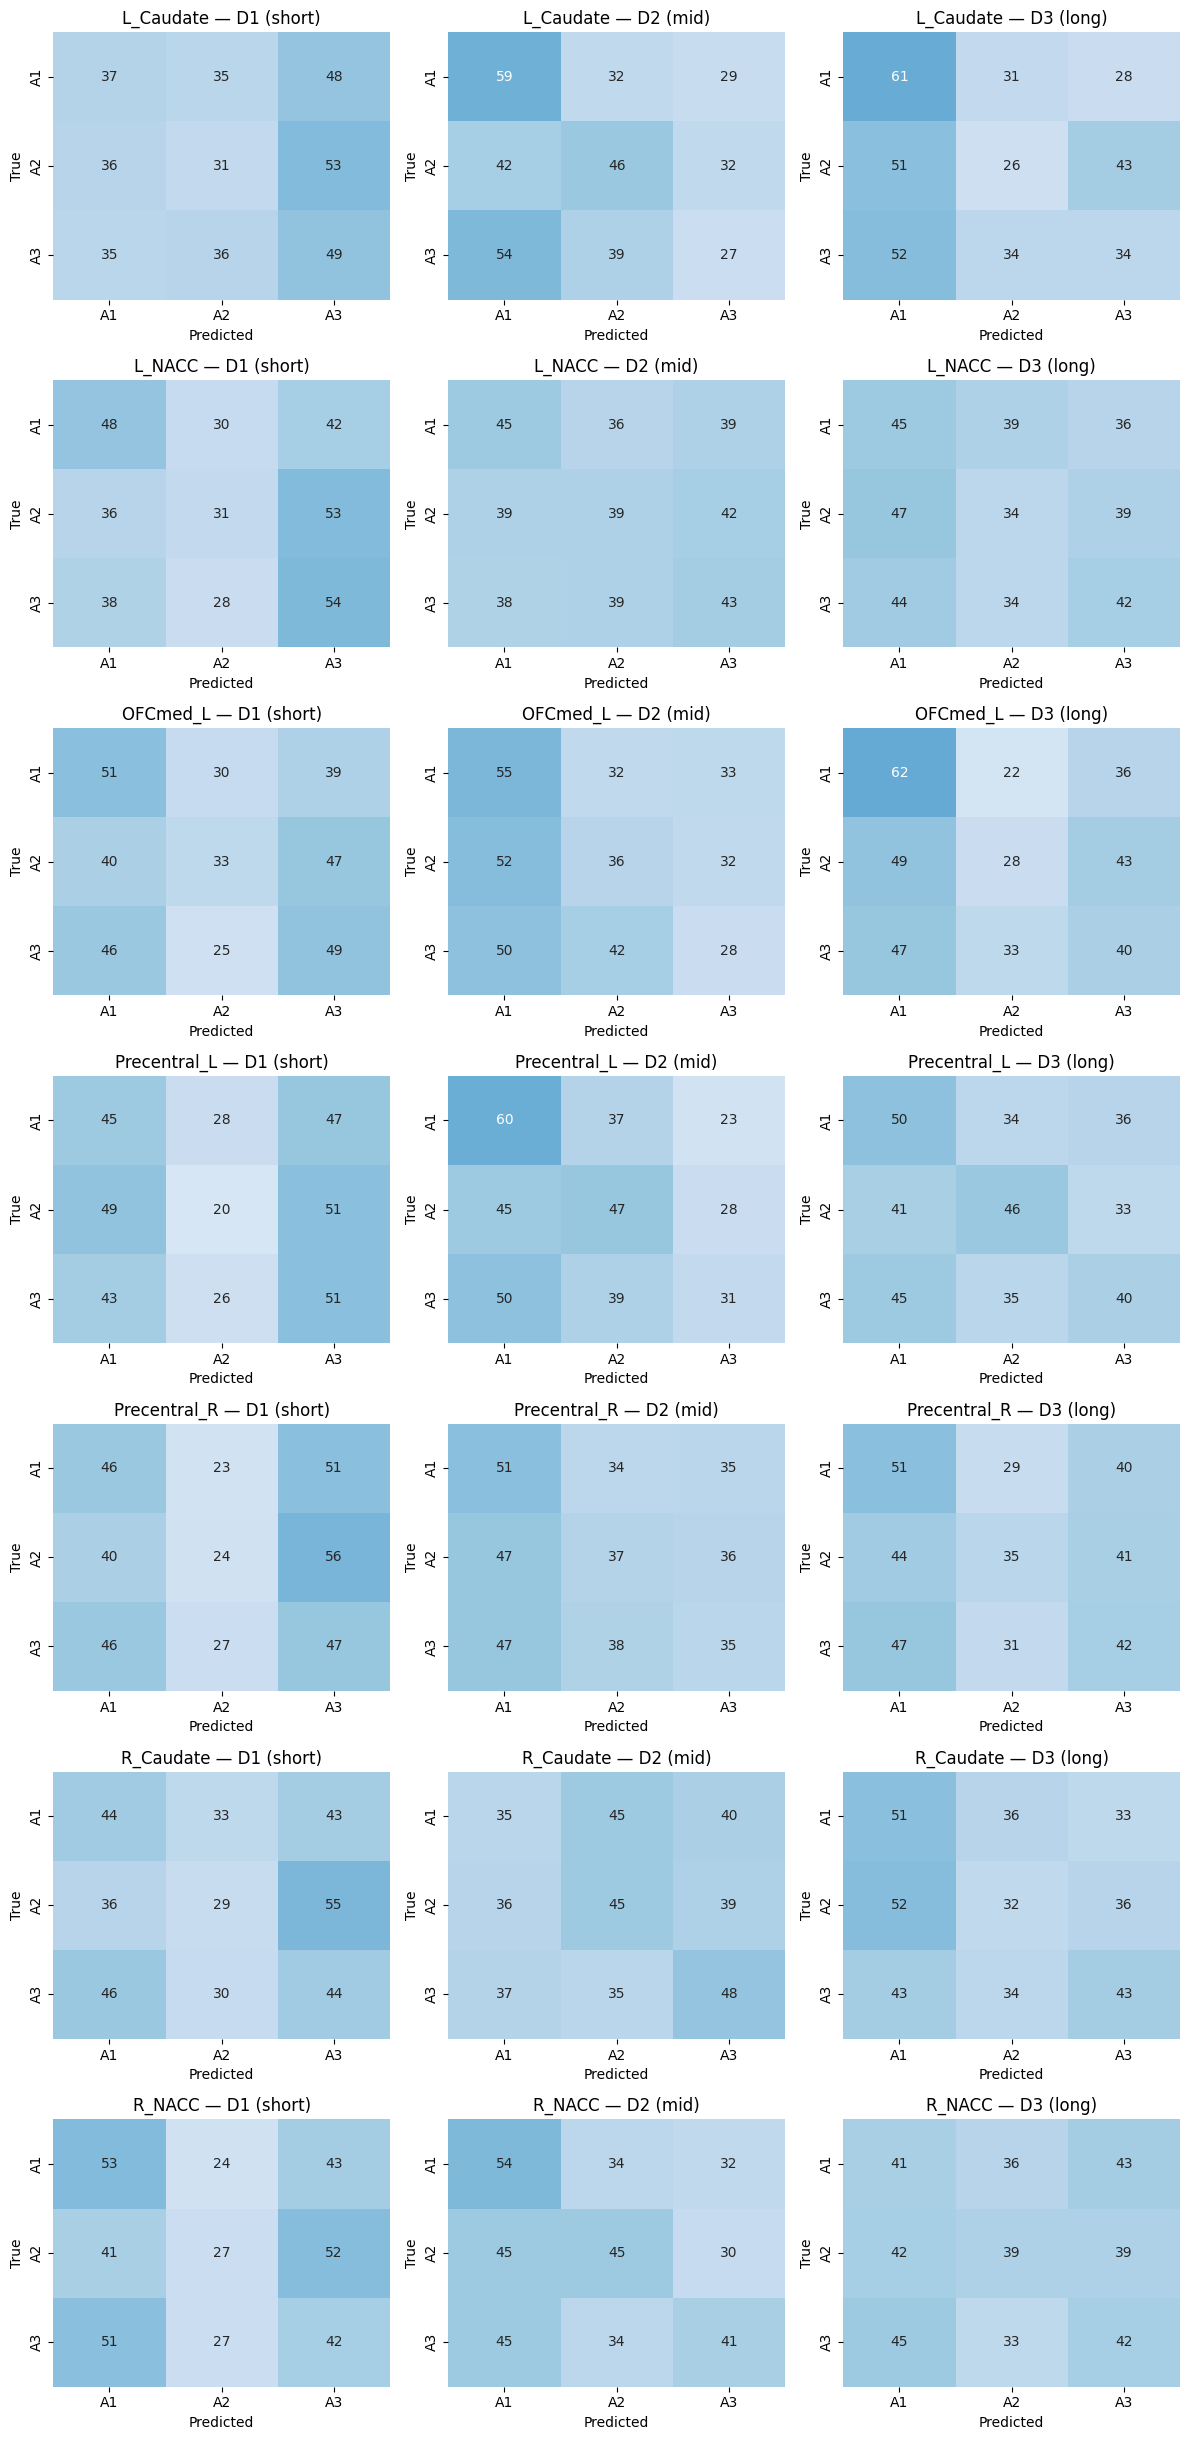

In [11]:
available_rois = sorted(conf_df['roi_name'].dropna().unique())
n_rois = len(available_rois)
n_delays = len(DELAY_BINS)

fig, axes = plt.subplots(n_rois, n_delays, figsize=(4 * n_delays, 3.5 * n_rois))
if n_rois == 1:
    axes = axes[np.newaxis, :]

for i, roi_name in enumerate(available_rois):
    for j, d in enumerate(DELAY_BINS):
        ax = axes[i, j]
        subset = conf_df[
            (conf_df['roi_name'] == roi_name) & (conf_df['delay_bin'] == d)
        ]
        if subset.empty:
            ax.set_visible(False)
            continue
        cm = subset.pivot(
            index='true_class', columns='pred_class', values='count'
        ).fillna(0)
        cm_norm = cm.div(cm.sum(axis=1), axis=0)
        sns.heatmap(
            cm_norm,
            annot=cm.astype(int),
            fmt='d',
            cmap='Blues',
            vmin=0,
            vmax=1,
            ax=ax,
            cbar=False,
            xticklabels=['A1', 'A2', 'A3'],
            yticklabels=['A1', 'A2', 'A3'],
        )
        ax.set_title(f'{roi_name} — {DELAY_LABELS[d]}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

plt.tight_layout()
plt.show()

---
## 7. Subject-level predictions

Check for outlier subjects driving group results.

In [12]:
pred_df['correct'] = (pred_df['y_true'] == pred_df['y_pred']).astype(int)

sub_acc = (
    pred_df.groupby(['sub_id', 'roi_name', 'delay_bin'])['correct']
    .mean()
    .reset_index()
    .rename(columns={'correct': 'accuracy'})
)

print('Per-subject accuracy distribution (pooled across ROIs and delay bins):')
print(sub_acc['accuracy'].describe().round(3))

Per-subject accuracy distribution (pooled across ROIs and delay bins):
count    2520.000
mean        0.350
std         0.209
min         0.000
25%         0.333
50%         0.333
75%         0.333
max         1.000
Name: accuracy, dtype: float64


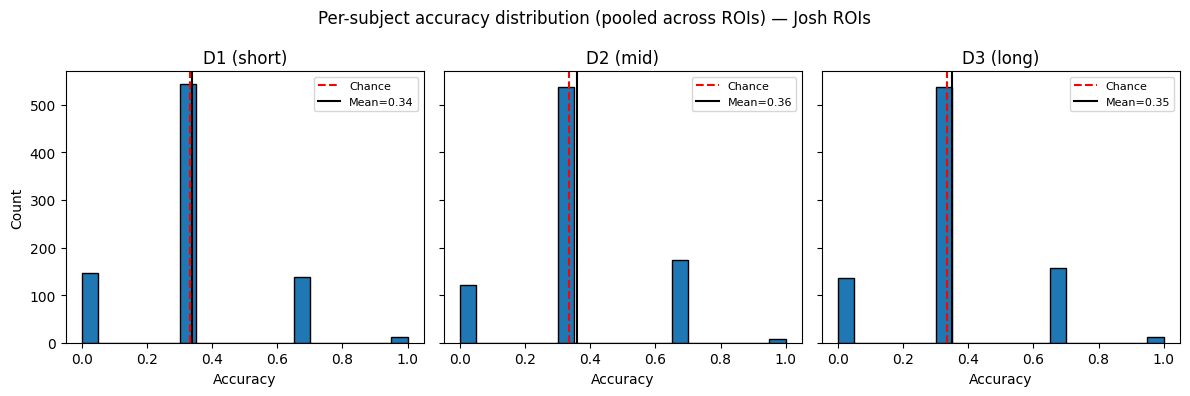

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)
for ax, d in zip(axes, DELAY_BINS):
    data = sub_acc[sub_acc['delay_bin'] == d]['accuracy']
    ax.hist(data, bins=20, edgecolor='k')
    ax.axvline(CHANCE, color='r', linestyle='--', label='Chance')
    ax.axvline(data.mean(), color='k', linestyle='-', label=f'Mean={data.mean():.2f}')
    ax.set_title(DELAY_LABELS[d])
    ax.set_xlabel('Accuracy')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Count')
plt.suptitle('Per-subject accuracy distribution (pooled across ROIs) — Josh ROIs')
plt.tight_layout()
plt.show()

---
## 8. Summary table

In [14]:
summary_cols = [
    'roi_name',
    'delay_bin',
    'n_subjects',
    'n_vox',
    'balanced_accuracy',
    'mean_auc',
    'f1_A1',
    'f1_A2',
    'f1_A3',
]

summary = (
    roi_df[summary_cols]
    .sort_values(['roi_name', 'delay_bin'])
    .round(3)
    .reset_index(drop=True)
)

summary

,roi_name,delay_bin,n_subjects,n_vox,balanced_accuracy,mean_auc,f1_A1,f1_A2,f1_A3
0,L_Caudate,1,120,1808,0.325,0.497,0.325,0.279,0.363
1,L_Caudate,2,120,1808,0.367,0.535,0.429,0.388,0.260
2,L_Caudate,3,120,1808,0.336,0.525,0.430,0.246,0.302
3,L_NACC,1,120,315,0.369,0.524,0.397,0.297,0.401
4,L_NACC,2,120,315,0.353,0.540,0.372,0.333,0.352
5,L_NACC,3,120,315,0.336,0.505,0.352,0.300,0.354
6,OFCmed_L,1,120,317,0.369,0.499,0.397,0.317,0.384
7,OFCmed_L,2,120,317,0.331,0.519,0.397,0.313,0.263
8,OFCmed_L,3,120,317,0.361,0.544,0.446,0.276,0.335
9,Precentral_L,1,120,2870,0.322,0.494,0.350,0.206,0.379
